# gps-athlete-analysis

## Phase 1: Data Quality

In [1]:
# Phase 1.1: Load CSV and Inspect

with open("../data/raw_data.csv") as f:
    for _ in range(3):
        print(f.readline())

time_iso_utc,x_pos_m,y_pos_m,latitude_deg,longitude_deg,speed_km_h,heartbeat_bpm

20181031T183138000,45.187631,26.145418,46.371289,6.22868,0.32184,160.06

20181031T183138100,45.112052,26.097923,46.371288,6.22868,0.63,160.06



In [2]:
# Phase 1.1: Load CSV and Inspect

import pandas as pd

df = pd.read_csv("../data/raw_data.csv" )

print(df.shape)
df.head()

(59551, 7)


,time_iso_utc,x_pos_m,y_pos_m,latitude_deg,longitude_deg,speed_km_h,heartbeat_bpm
0,20181031T183138000,45.187631,26.145418,46.371289,6.22868,0.32184,160.06
1,20181031T183138100,45.112052,26.097923,46.371288,6.22868,0.63000,160.06
2,20181031T183138200,45.032956,26.057272,46.371287,6.22868,0.94680,160.06
3,20181031T183138300,44.967264,26.014859,46.371286,6.22868,1.22724,160.06
4,20181031T183138400,44.902237,25.946833,46.371285,6.22868,1.53432,160.06


In [3]:
# Phase 1.1: Load CSV and Inspect

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 59551 entries, 0 to 59550
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_iso_utc   59551 non-null  str    
 1   x_pos_m        59551 non-null  float64
 2   y_pos_m        59551 non-null  float64
 3   latitude_deg   59551 non-null  float64
 4   longitude_deg  59551 non-null  float64
 5   speed_km_h     59551 non-null  float64
 6   heartbeat_bpm  59551 non-null  float64
dtypes: float64(6), str(1)
memory usage: 3.2 MB


,x_pos_m,y_pos_m,latitude_deg,longitude_deg,speed_km_h,heartbeat_bpm
count,59551.000000,59551.000000,59551.000000,59551.000000,59551.000000,59551.000000
mean,60.453614,32.046183,46.371435,6.228702,6.021030,148.990629
std,24.036997,18.453858,0.000225,0.000222,4.797636,23.428304
min,5.643389,2.817644,46.370884,6.227967,0.047880,86.030000
25%,42.659000,17.084070,46.371255,6.228556,2.692800,132.880000
50%,59.458456,25.491799,46.371419,6.228717,4.605480,151.640000
75%,77.991739,50.148508,46.371621,6.228844,8.501400,169.280000
max,114.276110,76.964532,46.372007,6.229331,27.398880,188.980000


In [4]:
# Phase 1.2: Check Timestamp Data Quality

df["time"] = pd.to_datetime(df["time_iso_utc"], format="%Y%m%dT%H%M%S%f")

print(df["time"].dtype)
print("start:", df["time"].min())
print("end:  ", df["time"].max())
print("duration:", df["time"].max() - df["time"].min())
print("duplicates:", df["time"].duplicated().sum())
print("sorted:", df["time"].is_monotonic_increasing)

datetime64[us]
start: 2018-10-31 18:31:38
end:   2018-10-31 20:25:39
duration: 0 days 01:54:01
duplicates: 0
sorted: True


In [5]:
# Phase 1.3: Sampling regularity and gaps

dt = df["time"].diff().dt.total_seconds()

print(dt.value_counts().head(10))
print("\ngaps > 0.11s:", (dt > 0.11).sum())
print("total missing time (s):", dt[dt > 0.11].sum() - 0.1 * (dt > 0.11).sum())

time
0.1      59549
886.1        1
Name: count, dtype: int64

gaps > 0.11s: 1
total missing time (s): 886.0


In [6]:
# Phase 1.3: Sampling regularity and gaps

gaps = df.loc[dt > 1, ["time"]].copy()
gaps["gap_seconds"] = dt[dt > 1]
gaps["gap_starts_at"] = df["time"].shift(1)[dt > 1]
gaps.sort_values("gap_seconds", ascending=False).head(15)

,time,gap_seconds,gap_starts_at
29733,2018-10-31 19:35:57.300,886.1,2018-10-31 19:21:11.200


In [7]:
# Phase 1.3: Sampling regularity and gaps

import numpy as np

df["dt"] = df["time"].diff().dt.total_seconds()
df.loc[df["dt"] > 0.11, "dt"] = np.nan       # don't compute across the gap
df["half"] = np.where(df.index >= 29733, "H2", "H1")

df["half"].value_counts()

half
H2    29818
H1    29733
Name: count, dtype: int64

In [8]:
# Phase 1.4: Value sanity checks

# --- 1) HR frozen-sensor check ---
hr_streak = df.groupby((df["heartbeat_bpm"] != df["heartbeat_bpm"].shift()).cumsum()).size()
print("longest run of identical HR values:", hr_streak.max(), "samples",
      f"({hr_streak.max() * 0.1:.1f}s)")
print("runs longer than 5s:", (hr_streak > 50).sum())

# --- 2) Out-of-bounds check ---
oob = (df["x_pos_m"] < 0) | (df["x_pos_m"] > 118) | (df["y_pos_m"] < 0) | (df["y_pos_m"] > 72)
print("\nout-of-bounds samples:", oob.sum(),
      f"({oob.sum() / len(df) * 100:.2f}% of session, {oob.sum() * 0.1:.0f}s total)")
print("max excursion beyond y=72:", (df.loc[oob, 'y_pos_m'] - 72).max().round(2), "m")
print("\nby half:")
print(df.loc[oob, "half"].value_counts())
print("\nfirst and last out-of-bounds moments:")
print(df.loc[oob, "time"].min(), "|", df.loc[oob, "time"].max())

longest run of identical HR values: 26 samples (2.6s)
runs longer than 5s: 0

out-of-bounds samples: 165 (0.28% of session, 16s total)
max excursion beyond y=72: 4.96 m

by half:
half
H1    153
H2     12
Name: count, dtype: int64

first and last out-of-bounds moments:
2018-10-31 19:20:56 | 2018-10-31 19:35:58.400000


correlation: 0.9361

mean device speed:   1.673 m/s
mean derived speed:  1.687 m/s
max derived speed:   8.29 m/s (29.9 km/h)

difference stats (derived - device):
count    59549.000
mean         0.015
std          0.484
min         -4.698
25%         -0.194
50%          0.025
75%          0.228
max          6.045
dtype: float64


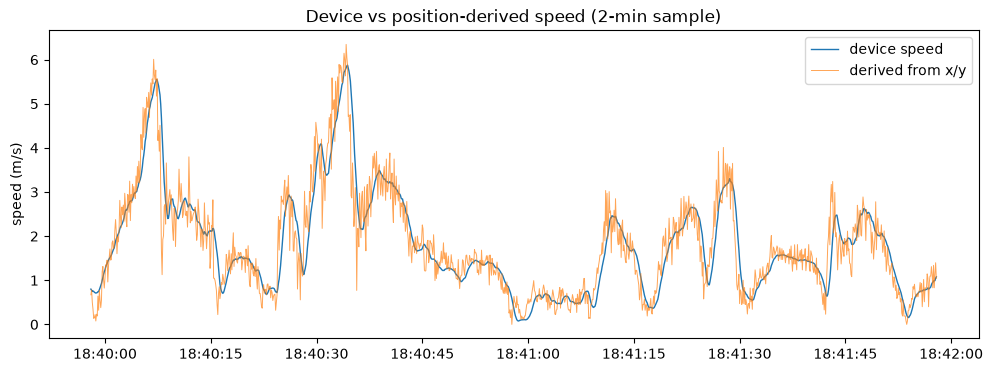

In [9]:
# Phase 1.5: Speed cross-validation

# displacement-derived speed (m/s), respecting the gap via our dt column
dx = df["x_pos_m"].diff()
dy = df["y_pos_m"].diff()
df["speed_derived_ms"] = np.sqrt(dx**2 + dy**2) / df["dt"]   # NaN at row 0 and at the gap

df["speed_ms"] = df["speed_km_h"] / 3.6

comp = df[["speed_ms", "speed_derived_ms"]].dropna()

print("correlation:", comp["speed_ms"].corr(comp["speed_derived_ms"]).round(4))
print("\nmean device speed:  ", comp["speed_ms"].mean().round(3), "m/s")
print("mean derived speed: ", comp["speed_derived_ms"].mean().round(3), "m/s")
print("max derived speed:  ", comp["speed_derived_ms"].max().round(2), "m/s",
      f"({comp['speed_derived_ms'].max() * 3.6:.1f} km/h)")

diff = comp["speed_derived_ms"] - comp["speed_ms"]
print("\ndifference stats (derived - device):")
print(diff.describe().round(3))

# quick visual: overlay a 2-minute window
import matplotlib.pyplot as plt
w = df.iloc[5000:6200]
plt.figure(figsize=(12, 4))
plt.plot(w["time"], w["speed_ms"], label="device speed", linewidth=1)
plt.plot(w["time"], w["speed_derived_ms"], label="derived from x/y", linewidth=0.7, alpha=0.7)
plt.ylabel("speed (m/s)"); plt.legend(); plt.title("Device vs position-derived speed (2-min sample)")
plt.show()

## Phase 1 - Data Quality Summary

**Dataset:** 
59,551 rows × 7 columns; 10 Hz GPS + heart rate from one athlete, 2018-10-31, 18:31:38–20:25:39 UTC (evening session).

**Completeness & Integrity**
- No missing values in any column; all dtypes correct after parsing.
- Timestamps in compact ISO format (`%Y%m%dT%H%M%S%f`); parsed explicitly. No duplicates, strictly ordered.

**Sampling continuity**
- Recording spans 114 min, but samples cover ~99 min: a single gap of 886 s (14.8 min) at 19:21:11 → 19:35:57. All other 59,549 intervals are exactly 0.1 s.
- The gap splits the session into two ~50-min halves (interpreted as a halftime-style break). Encoded as `half` (H1: 29,733 / H2: 29,818 rows); `dt` set to NaN at the gap so no distance/acceleration is computed across it.

**Value plausibility**
- Speed 0.05–27.4 km/h; HR 86–189 bpm; positions span ~109 × 74 m within a given 118 × 72 m field — all plausible for football-format training.
- HR sensor check: longest run of identical values = 2.6 s; no frozen stretches.
- 165 samples (16 s, 0.28%) lie up to ~5 m beyond the y = 72 sideline; all occur in the 15 s before / 1 s after the halftime gap (athlete walking off-pitch during the break). Positions are genuine; no correction

**Speed validation**
- Position-derived speed vs device speed: r = 0.936 raw, mean difference 0.015 m/s, no bias.
- Decision: device `speed_km_h` used for all speed/distance/acceleration metrics (already device-filtered); positions used for spatial analysis only.

**Known limitations**
- Athlete identity, sport, sex, age and max HR unknown; football was the sport assumed based on field dimensions; session-max HR (189 bpm) used as max-HR proxy for HR zones.

## Phase 2: Analysis

In [10]:
# Phase 2.1: speed_ms

print(df["speed_ms"].describe().round(3))

count    59551.000
mean         1.673
std          1.333
min          0.013
25%          0.748
50%          1.279
75%          2.362
max          7.611
Name: speed_ms, dtype: float64


In [11]:
# Phase 2.2: distance

# distance per sample: v * dt  (gap row contributes nothing because dt is NaN there)
df["dist_m"] = df["speed_ms"] * df["dt"]

# cumulative distance across the session
df["dist_cum_m"] = df["dist_m"].cumsum().fillna(0)

total = df["dist_m"].sum()
by_half = df.groupby("half")["dist_m"].sum()

print(f"total distance: {total:,.0f} m  ({total/1000:.2f} km)")
print(f"\nby half:")
print(by_half.round(0))
print(f"\nH2 vs H1: {(by_half['H2'] / by_half['H1'] - 1) * 100:+.1f}%")

# cross-check against displacement-derived distance
disp = (np.sqrt(df["x_pos_m"].diff()**2 + df["y_pos_m"].diff()**2)
        .where(df["dt"].notna()).sum())
print(f"\ncross-check (summed displacements): {disp:,.0f} m "
      f"({(disp/total - 1)*100:+.1f}% vs speed-based)")


total distance: 9,960 m  (9.96 km)

by half:
half
H1    5137.0
H2    4823.0
Name: dist_m, dtype: float64

H2 vs H1: -6.1%

cross-check (summed displacements): 10,047 m (+0.9% vs speed-based)


mean |change|: 0.0131 m/s
max  |change|: 0.248 m/s
max smooth speed: 7.589 m/s (27.3 km/h)
when session peak: 2018-10-31 20:23:08.800000


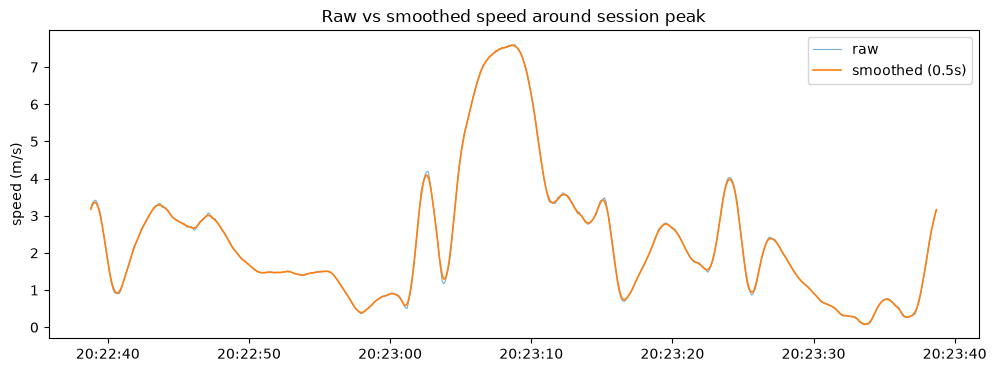

In [12]:

# Phase 2.3: Speed smoothing

# centered 0.5s rolling mean, computed per half so the window never spans the gap
df["speed_smooth_ms"] = (
    df.groupby("half")["speed_ms"]
      .transform(lambda s: s.rolling(window=5, center=True, min_periods=1).mean())
)

# how much did smoothing change things? (should be: barely)
delta = df["speed_ms"] - df["speed_smooth_ms"]
print("mean |change|:", delta.abs().mean().round(4), "m/s")
print("max  |change|:", delta.abs().max().round(3), "m/s")
print("max smooth speed:", df["speed_smooth_ms"].max().round(3), "m/s",
      f"({df['speed_smooth_ms'].max()*3.6:.1f} km/h)")

# exact timestamp of session peak speed
print("when session peak:", df.loc[df["speed_ms"].idxmax(), "time"])

# visual: raw vs smooth on a sprint-ish window (highest-speed moment)
peak_i = df["speed_ms"].idxmax()
w = df.iloc[max(0, peak_i-300):peak_i+300]
plt.figure(figsize=(12, 4))
plt.plot(w["time"], w["speed_ms"], label="raw", linewidth=0.8, alpha=0.6)
plt.plot(w["time"], w["speed_smooth_ms"], label="smoothed (0.5s)", linewidth=1.2)
plt.ylabel("speed (m/s)"); plt.legend(); plt.title("Raw vs smoothed speed around session peak")
plt.show()

count    59549.000
mean         0.000
std          0.713
min         -4.773
25%         -0.250
50%         -0.004
75%          0.266
max          4.096
Name: accel_ms2, dtype: float64

samples with |a| > 4 m/s²: 25
samples with |a| > 6 m/s²: 0


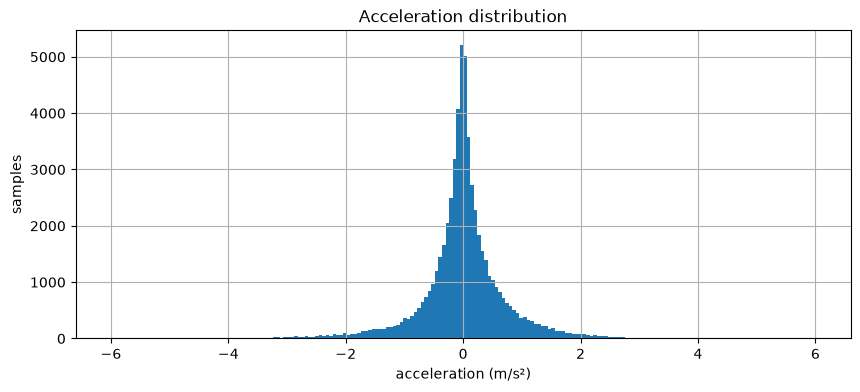

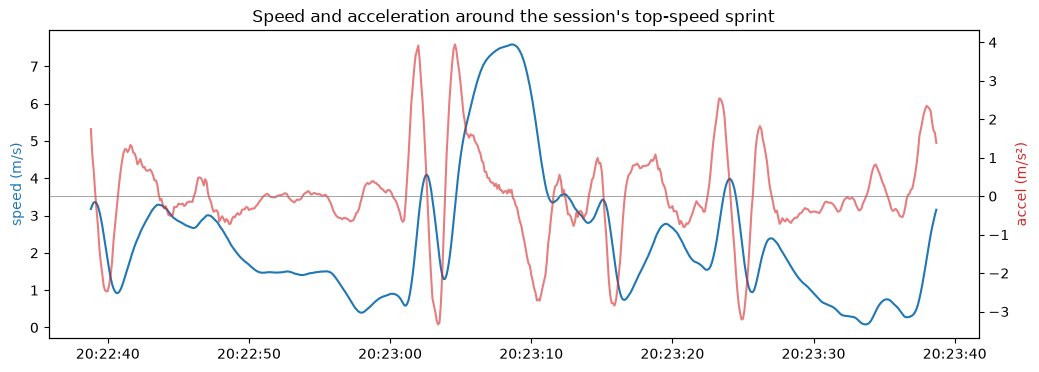

In [13]:
# Phase 2.4: Acceleration

# acceleration = Δv/Δt on smoothed speed, computed within each half
df["accel_ms2"] = (
    df.groupby("half")["speed_smooth_ms"].diff() / df["dt"]
)

print(df["accel_ms2"].describe().round(3))
print("\nsamples with |a| > 4 m/s²:", (df["accel_ms2"].abs() > 4).sum())
print("samples with |a| > 6 m/s²:", (df["accel_ms2"].abs() > 6).sum())

# distribution shape
plt.figure(figsize=(10, 4))
df["accel_ms2"].hist(bins=200, range=(-6, 6))
plt.xlabel("acceleration (m/s²)"); plt.ylabel("samples")
plt.title("Acceleration distribution")
plt.show()

# acceleration trace around the known sprint, as a visual sanity check
peak_i = df["speed_ms"].idxmax()
w = df.iloc[peak_i-300:peak_i+300]
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(w["time"], w["speed_smooth_ms"], color="tab:blue", label="speed (m/s)")
ax1.set_ylabel("speed (m/s)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(w["time"], w["accel_ms2"], color="tab:red", alpha=0.6, label="accel (m/s²)")
ax2.set_ylabel("accel (m/s²)", color="tab:red")
ax2.axhline(0, color="gray", linewidth=0.5)
plt.title("Speed and acceleration around the session's top-speed sprint")
plt.show()

In [14]:
# Phase 2.5: Speed Zones

# football-convention zones (km/h): standing <1, walking 1–7, jogging 7–14,
# running 14–20, high-speed 20–25, sprinting >25
zone_edges  = [0, 1, 7, 14, 20, 25, np.inf]
zone_labels = ["standing", "walking", "jogging", "running", "high-speed", "sprinting"]

df["speed_smooth_kmh"] = df["speed_smooth_ms"] * 3.6
df["speed_zone"] = pd.cut(df["speed_smooth_kmh"], bins=zone_edges,
                          labels=zone_labels, right=False)

# time (min) and distance (m) per zone, overall
zone_summary = df.groupby("speed_zone", observed=True).agg(
    time_min=("dt", lambda s: s.sum() / 60),
    dist_m=("dist_m", "sum"),
).round(1)
zone_summary["time_pct"] = (zone_summary["time_min"] / zone_summary["time_min"].sum() * 100).round(1)
zone_summary["dist_pct"] = (zone_summary["dist_m"] / zone_summary["dist_m"].sum() * 100).round(1)
print(zone_summary)

# distance per zone per half — the fatigue question
by_half = (df.groupby(["speed_zone", "half"], observed=True)["dist_m"].sum()
             .unstack("half").round(0))
by_half["H2_vs_H1_pct"] = ((by_half["H2"] / by_half["H1"] - 1) * 100).round(1)
print("\n", by_half)

            time_min  dist_m  time_pct  dist_pct
speed_zone                                      
standing         9.5    64.5       9.6       0.6
walking         59.1  3745.2      59.5      37.6
jogging         22.8  3850.4      22.9      38.7
running          6.7  1835.0       6.7      18.4
high-speed       1.1   388.6       1.1       3.9
sprinting        0.2    76.1       0.2       0.8

 half            H1      H2  H2_vs_H1_pct
speed_zone                              
standing      27.0    38.0          40.7
walking     1927.0  1818.0          -5.7
jogging     1948.0  1902.0          -2.4
running      943.0   892.0          -5.4
high-speed   239.0   149.0         -37.7
sprinting     53.0    24.0         -54.7


In [15]:
# Phase 2.6: Sprint Detection

def detect_episodes(df, threshold_kmh, min_duration_s=1.0):
    """Contiguous episodes where speed_smooth_kmh >= threshold within each half."""
    above = df["speed_smooth_kmh"] >= threshold_kmh
    # new episode when 'above' switches on or when half changes mid-run
    episode_id = ((above != above.shift()) | (df["half"] != df["half"].shift())).cumsum()
    episodes = []
    for _, g in df[above].groupby(episode_id[above]):
        duration = g["dt"].sum()
        if pd.isna(duration) or duration + 0.1 < min_duration_s:  # dt of first row counts
            continue
        episodes.append({
            "start": g["time"].iloc[0],
            "end": g["time"].iloc[-1],
            "half": g["half"].iloc[0],
            "duration_s": round(g["dt"].sum() + 0.1, 1),   # +0.1: include first sample
            "distance_m": round(g["dist_m"].sum(), 1),
            "peak_kmh": round(g["speed_smooth_kmh"].max(), 2),
        })
    return pd.DataFrame(episodes)

sprints_25 = detect_episodes(df, 25.0)
sprints_21 = detect_episodes(df, 21.0)

print(f"=== threshold 25 km/h: {len(sprints_25)} sprints ===")
print(sprints_25)
print(f"\n=== threshold 21 km/h: {len(sprints_21)} sprints ===")
print(sprints_21)
print("\nby half (21 km/h):", sprints_21["half"].value_counts().to_dict() if len(sprints_21) else "-")


=== threshold 25 km/h: 4 sprints ===
                    start                     end half  duration_s  \
0 2018-10-31 18:35:22.800 2018-10-31 18:35:24.200   H1         1.6   
1 2018-10-31 18:47:24.100 2018-10-31 18:47:26.300   H1         2.4   
2 2018-10-31 18:49:11.500 2018-10-31 18:49:14.800   H1         3.5   
3 2018-10-31 20:23:06.500 2018-10-31 20:23:09.600   H2         3.3   

   distance_m  peak_kmh  
0        11.0     27.03  
1        16.6     26.23  
2        25.0     27.08  
3        23.6     27.32  

=== threshold 21 km/h: 18 sprints ===
                     start                     end half  duration_s  \
0  2018-10-31 18:35:17.300 2018-10-31 18:35:20.100   H1         3.0   
1  2018-10-31 18:35:21.900 2018-10-31 18:35:24.600   H1         2.9   
2  2018-10-31 18:37:03.200 2018-10-31 18:37:08.000   H1         5.0   
3  2018-10-31 18:47:22.800 2018-10-31 18:47:27.000   H1         4.4   
4  2018-10-31 18:49:10.600 2018-10-31 18:49:15.400   H1         5.0   
5  2018-10-31 18:

In [16]:
# Phase 2.6: Sprint Detection

agg = sprints_21.groupby("half").agg(
    n=("half", "size"),
    total_dist_m=("distance_m", "sum"),
    mean_dist_m=("distance_m", "mean"),
    mean_duration_s=("duration_s", "mean"),
    max_peak_kmh=("peak_kmh", "max"),
    n_peaks_over_25=("peak_kmh", lambda s: (s >= 25).sum()),
)
print(agg.round(2))

      n  total_dist_m  mean_dist_m  mean_duration_s  max_peak_kmh  \
half                                                                
H1    9         204.3        22.70             3.57         27.08   
H2    9         123.4        13.71             2.23         27.32   

      n_peaks_over_25  
half                   
H1                  3  
H2                  1  


In [17]:
# Phase 2.7: High-intensity acceleration/deceleration events

def detect_signal_episodes(df, mask, min_duration_s=0.5):
    """Contiguous episodes where mask is True within each half."""
    episode_id = ((mask != mask.shift()) | (df["half"] != df["half"].shift())).cumsum()
    episodes = []
    for _, g in df[mask].groupby(episode_id[mask]):
        duration = g["dt"].sum() + 0.1
        if pd.isna(duration) or duration < min_duration_s:
            continue
        episodes.append({
            "start": g["time"].iloc[0],
            "half": g["half"].iloc[0],
            "duration_s": round(duration, 1),
            "peak_a": round(g["accel_ms2"].abs().max(), 2),
        })
    return pd.DataFrame(episodes)

accels = detect_signal_episodes(df, df["accel_ms2"] > 3)
decels = detect_signal_episodes(df, df["accel_ms2"] < -3)

print(f"accel events (>+3 m/s², ≥0.5s): {len(accels)}")
print(accels.groupby("half").agg(n=("half", "size"), mean_peak=("peak_a", "mean")).round(2)
      if len(accels) else "-")
print(f"\ndecel events (<-3 m/s², ≥0.5s): {len(decels)}")
print(decels.groupby("half").agg(n=("half", "size"), mean_peak=("peak_a", "mean")).round(2)
      if len(decels) else "-")

accel events (>+3 m/s², ≥0.5s): 12
      n  mean_peak
half              
H1    4       3.40
H2    8       3.68

decel events (<-3 m/s², ≥0.5s): 31
       n  mean_peak
half               
H1    15       3.64
H2    16       3.67


In [18]:
# Phase 2.8: Heart rate zones

hr_max = df["heartbeat_bpm"].max()
print("HR max (proxy):", hr_max)

df["hr_pct"] = df["heartbeat_bpm"] / hr_max * 100

hr_edges  = [0, 60, 70, 80, 90, 100.0001]   # % of max; top edge inclusive of 100
hr_labels = ["<60%", "60-70%", "70-80%", "80-90%", "90-100%"]
df["hr_zone"] = pd.cut(df["hr_pct"], bins=hr_edges, labels=hr_labels, right=False)

# time per zone, total and per half
hr_time = (df.groupby(["hr_zone", "half"], observed=True)["dt"].sum() / 60).unstack("half").round(1)
hr_time["total_min"] = hr_time.sum(axis=1).round(1)
hr_time["total_pct"] = (hr_time["total_min"] / hr_time["total_min"].sum() * 100).round(1)
print("\ntime in HR zones (min):")
print(hr_time)

# mean/median HR per half
print("\nHR per half:")
print(df.groupby("half")["heartbeat_bpm"].agg(["mean", "median", "max"]).round(1))

HR max (proxy): 188.98

time in HR zones (min):
half       H1    H2  total_min  total_pct
hr_zone                                  
<60%      NaN  10.6       10.6       10.7
60-70%    9.6   4.3       13.9       14.0
70-80%    8.4  16.3       24.7       24.9
80-90%   11.6  14.8       26.4       26.6
90-100%  19.9   3.7       23.6       23.8

HR per half:
       mean  median    max
half                      
H1    157.2   161.9  189.0
H2    140.8   145.8  183.5


In [19]:
# Phase 2.9: Session segmentation into blocks

# elapsed time (s) within each half, from that half's first sample
half_start = df.groupby("half")["time"].transform("min")
df["elapsed_in_half_s"] = (df["time"] - half_start).dt.total_seconds()

# 15-min blocks within each half: H1-B1, H1-B2, ...
df["block_num"] = (df["elapsed_in_half_s"] // 900).astype(int) + 1
df["block"] = df["half"] + "-B" + df["block_num"].astype(str)

# overview: duration, distance, mean HR per block (order preserved)
block_overview = df.groupby("block", sort=False).agg(
    start=("time", "min"),
    duration_min=("dt", lambda s: round(s.sum() / 60, 1)),
    dist_m=("dist_m", lambda s: round(s.sum(), 0)),
    mean_hr=("heartbeat_bpm", lambda s: round(s.mean(), 1)),
)
block_overview["dist_per_min"] = (block_overview["dist_m"] / block_overview["duration_min"]).round(1)
print(block_overview)


#where do the <60% HR minutes actually live?
print("\n<60% HR minutes:")
print((df[df["hr_pct"] < 60].groupby("block", sort=False)["dt"].sum() / 60).round(1))

                        start  duration_min  dist_m  mean_hr  dist_per_min
block                                                                     
H1-B1 2018-10-31 18:31:38.000          15.0  1713.0    147.3         114.2
H1-B2 2018-10-31 18:46:38.000          15.0  1741.0    158.2         116.1
H1-B3 2018-10-31 19:01:38.000          15.0  1273.0    170.0          84.9
H1-B4 2018-10-31 19:16:38.000           4.6   411.0    143.9          89.3
H2-B1 2018-10-31 19:35:57.300          15.0  1502.0    121.6         100.1
H2-B2 2018-10-31 19:50:57.300          15.0  1307.0    149.3          87.1
H2-B3 2018-10-31 20:05:57.300          15.0  1543.0    150.5         102.9
H2-B4 2018-10-31 20:20:57.300           4.7   472.0    144.3         100.4

<60% HR minutes:
block
H2-B1    9.4
H2-B3    1.0
H2-B4    0.2
Name: dt, dtype: float64


## Phase 3 - Metrics Summary

In [20]:
# Phase 3.1: Training Session Summary

d = df
hi = d.speed_smooth_kmh >= 20
summary = {
    "Session date": d["time"].iloc[0].strftime("%Y-%m-%d"),
    "Start / End (UTC)": f'{d["time"].min().strftime("%H:%M:%S")} – {d["time"].max().strftime("%H:%M:%S")}',
    "Recorded duration (min)": round(d["dt"].sum() / 60, 1),
    "Halves (break)": "2 × ~49.5 min (14.8-min break)",
    "Total distance (m)": round(d["dist_m"].sum(), 0),
    "Total distance H1 / H2 (m)": f'{round(d[d.half=="H1"].dist_m.sum(),0)} / {round(d[d.half=="H2"].dist_m.sum(),0)}',
    "Distance >20 km/h (m)": round(d[hi].dist_m.sum(), 0),
    "Distance >20 km/h H1 / H2 (m)": f'{round(d[(d.half=="H1")&hi].dist_m.sum(),0)} / {round(d[(d.half=="H2")&hi].dist_m.sum(),0)}',
    "Max speed (km/h)": round(d["speed_smooth_kmh"].max(), 2),
    "Max speed reached at": d.loc[d["speed_ms"].idxmax(), "time"].strftime("%H:%M:%S.%f")[:-3],
    "Sprints ≥25 km/h (n)": len(sprints_25),
    "Sprints ≥21 km/h (n)": len(sprints_21),
    "Sprints ≥21 km/h H1 / H2": f'{(sprints_21.half=="H1").sum()} / {(sprints_21.half=="H2").sum()}',
    "Accel events >3 m/s² (n)": len(accels),
    "Decel events <-3 m/s² (n)": len(decels),
    "Mean HR (bpm)": round(d["heartbeat_bpm"].mean(), 1),
    "Mean HR H1 / H2 (bpm)": f'{round(d[d.half=="H1"].heartbeat_bpm.mean(),1)} / {round(d[d.half=="H2"].heartbeat_bpm.mean(),1)}',
    "Max HR (bpm)": round(d["heartbeat_bpm"].max(), 1),
    "Time ≥90% HRmax (min)": round(d[d.hr_pct >= 90].dt.sum() / 60, 1),
}
summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
print(summary_df.to_string())

                                                        value
Session date                                       2018-10-31
Start / End (UTC)                         18:31:38 – 20:25:39
Recorded duration (min)                                  99.2
Halves (break)                 2 × ~49.5 min (14.8-min break)
Total distance (m)                                     9960.0
Total distance H1 / H2 (m)                    5137.0 / 4823.0
Distance >20 km/h (m)                                   465.0
Distance >20 km/h H1 / H2 (m)                   292.0 / 173.0
Max speed (km/h)                                        27.32
Max speed reached at                             20:23:08.800
Sprints ≥25 km/h (n)                                        4
Sprints ≥21 km/h (n)                                       18
Sprints ≥21 km/h H1 / H2                                9 / 9
Accel events >3 m/s² (n)                                   12
Decel events <-3 m/s² (n)                                  31
Mean HR 

In [21]:
# Phase 3.2: Fatigue metrics per block & efficiency index

block_metrics = df.groupby("block", sort=False).agg(
    start=("time", "min"),
    duration_min=("dt", lambda s: round(s.sum()/60, 1)),
    dist_m=("dist_m", lambda s: round(s.sum(), 0)),
    mean_hr=("heartbeat_bpm", lambda s: round(s.mean(), 1)),
    mean_speed_ms=("speed_ms", lambda s: round(s.mean(), 3)),
)
block_metrics["dist_per_min"] = (block_metrics["dist_m"] / block_metrics["duration_min"]).round(1)

# efficiency index: metres covered per heartbeat
#   = (distance/min) / (beats/min) = m per beat.  Higher = more running per unit HR cost.
block_metrics["m_per_beat"] = (block_metrics["dist_per_min"] / block_metrics["mean_hr"]).round(3)

# high-speed distance per block, to see where sustained running concentrates
hi = df["speed_smooth_kmh"] >= 20
block_metrics["dist_over20_m"] = df[hi].groupby(df["block"], sort=False)["dist_m"].sum().round(0)
block_metrics["dist_over20_m"] = block_metrics["dist_over20_m"].fillna(0)

print(block_metrics.to_string())



                        start  duration_min  dist_m  mean_hr  mean_speed_ms  dist_per_min  m_per_beat  dist_over20_m
block                                                                                                               
H1-B1 2018-10-31 18:31:38.000          15.0  1713.0    147.3          1.903         114.2       0.775          112.0
H1-B2 2018-10-31 18:46:38.000          15.0  1741.0    158.2          1.934         116.1       0.734          153.0
H1-B3 2018-10-31 19:01:38.000          15.0  1273.0    170.0          1.415          84.9       0.499           20.0
H1-B4 2018-10-31 19:16:38.000           4.6   411.0    143.9          1.502          89.3       0.621            7.0
H2-B1 2018-10-31 19:35:57.300          15.0  1502.0    121.6          1.668         100.1       0.823           37.0
H2-B2 2018-10-31 19:50:57.300          15.0  1307.0    149.3          1.452          87.1       0.583           18.0
H2-B3 2018-10-31 20:05:57.300          15.0  1543.0    150.5    

## Phase 4 - Visualizations

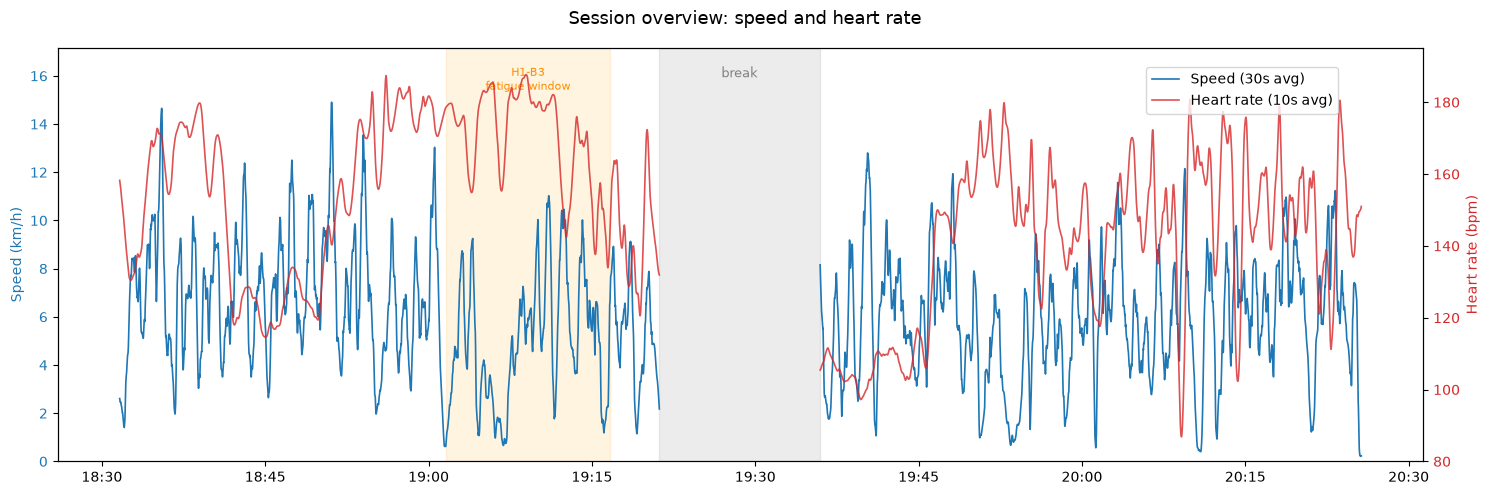

In [22]:
# Phase 4.1: Speed + HR time series

import matplotlib.dates as mdates

# 30s rolling speed envelope (per half) in km/h; 10s light HR smooth (per half)
df["speed_env_kmh"] = df.groupby("half")["speed_smooth_kmh"].transform(
    lambda s: s.rolling(300, center=True, min_periods=1).mean())
df["hr_plot"] = df.groupby("half")["heartbeat_bpm"].transform(
    lambda s: s.rolling(100, center=True, min_periods=1).mean())

fig, ax1 = plt.subplots(figsize=(15, 5))

# speed envelope, each half separately so the break stays blank
for h in ["H1", "H2"]:
    g = df[df["half"] == h]
    ax1.plot(g["time"], g["speed_env_kmh"], color="tab:blue", linewidth=1.2,
             label="Speed (30s avg)" if h == "H1" else None)
ax1.set_ylabel("Speed (km/h)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, df["speed_env_kmh"].max() * 1.15)

ax2 = ax1.twinx()
for h in ["H1", "H2"]:
    g = df[df["half"] == h]
    ax2.plot(g["time"], g["hr_plot"], color="tab:red", linewidth=1.2, alpha=0.8,
             label="Heart rate (10s avg)" if h == "H1" else None)
ax2.set_ylabel("Heart rate (bpm)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(80, 195)

# shade the halftime break
gap_start = df[df.half == "H1"]["time"].max()
gap_end   = df[df.half == "H2"]["time"].min()
ax1.axvspan(gap_start, gap_end, color="gray", alpha=0.15)
ax1.text(gap_start + (gap_end - gap_start) / 2, df["speed_env_kmh"].max() * 1.1,
         "break", ha="center", va="top", fontsize=9, color="gray")

# shade the fatigue window H1-B3
b3 = df[df.block == "H1-B3"]
ax1.axvspan(b3["time"].min(), b3["time"].max(), color="orange", alpha=0.12)
ax1.text(b3["time"].min() + (b3["time"].max() - b3["time"].min()) / 2,
         df["speed_env_kmh"].max() * 1.1,
         "H1-B3\nfatigue window", ha="center", va="top", fontsize=8, color="darkorange")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle("Session overview: speed and heart rate", fontsize=13)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig("../images/01_session_overview.png", dpi=150, bbox_inches="tight")
plt.show()

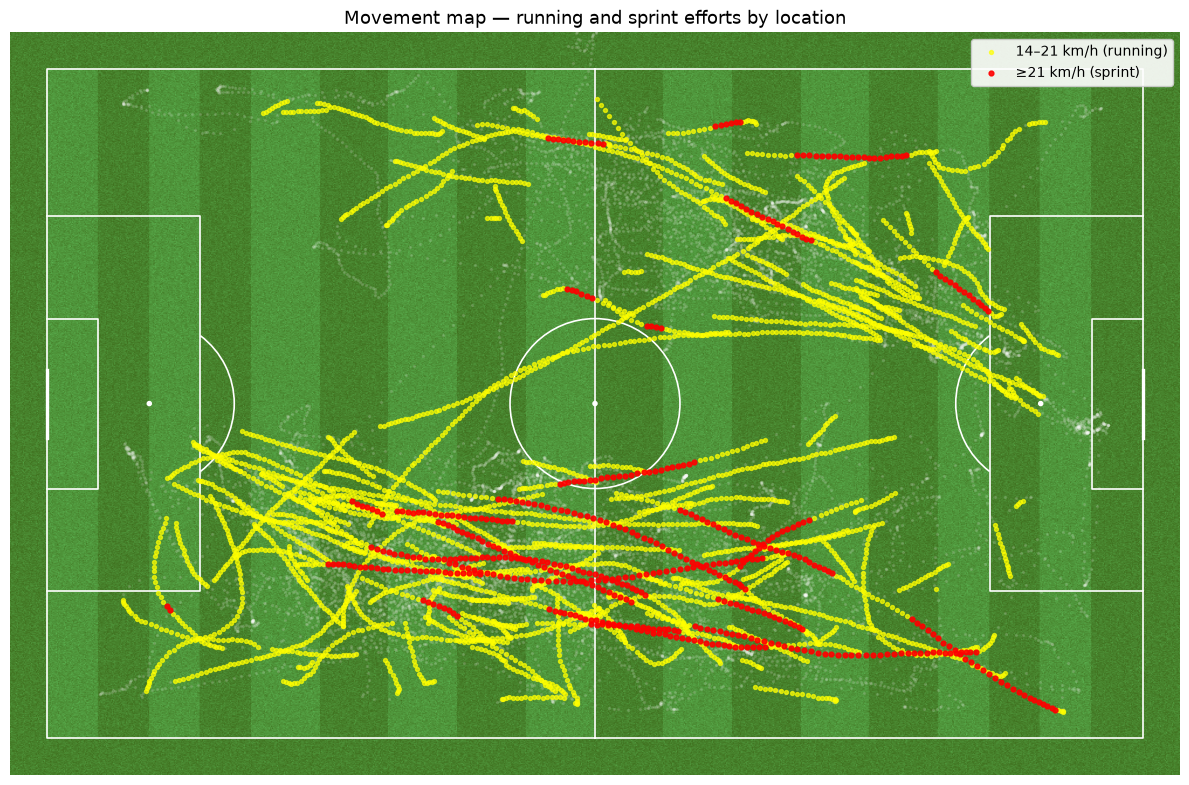

In [23]:
# Phase 4.2: Pitch trajectory / sprint map

from mplsoccer import Pitch

pitch = Pitch(pitch_type='custom', pitch_length=118, pitch_width=72,
              pitch_color='grass', stripe=True,
              line_color='white', linewidth=1.2)

# tiers on smoothed speed
run_mask    = (df["speed_smooth_kmh"] >= 14) & (df["speed_smooth_kmh"] < 21)
sprint_mask =  df["speed_smooth_kmh"] >= 21

fig, ax = pitch.draw(figsize=(12, 8))

# tier 0: faint everything-else context (below 14 km/h), subsampled
low = df[df["speed_smooth_kmh"] < 14].iloc[::5]
pitch.scatter(low["x_pos_m"], low["y_pos_m"],
              color="white", s=2, alpha=0.12, ax=ax)

# tier 1: running 14–21 km/h
pitch.scatter(df.loc[run_mask, "x_pos_m"], df.loc[run_mask, "y_pos_m"],
              color="yellow", s=8, alpha=0.7, ax=ax, label="14–21 km/h (running)")

# tier 2: sprint ≥21 km/h
pitch.scatter(df.loc[sprint_mask, "x_pos_m"], df.loc[sprint_mask, "y_pos_m"],
              color="red", s=12, alpha=0.9, ax=ax, label="≥21 km/h (sprint)")

ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("Movement map — running and sprint efforts by location", fontsize=13)
fig.savefig("../images/02_movement_map.png", dpi=150, bbox_inches="tight")
plt.show()

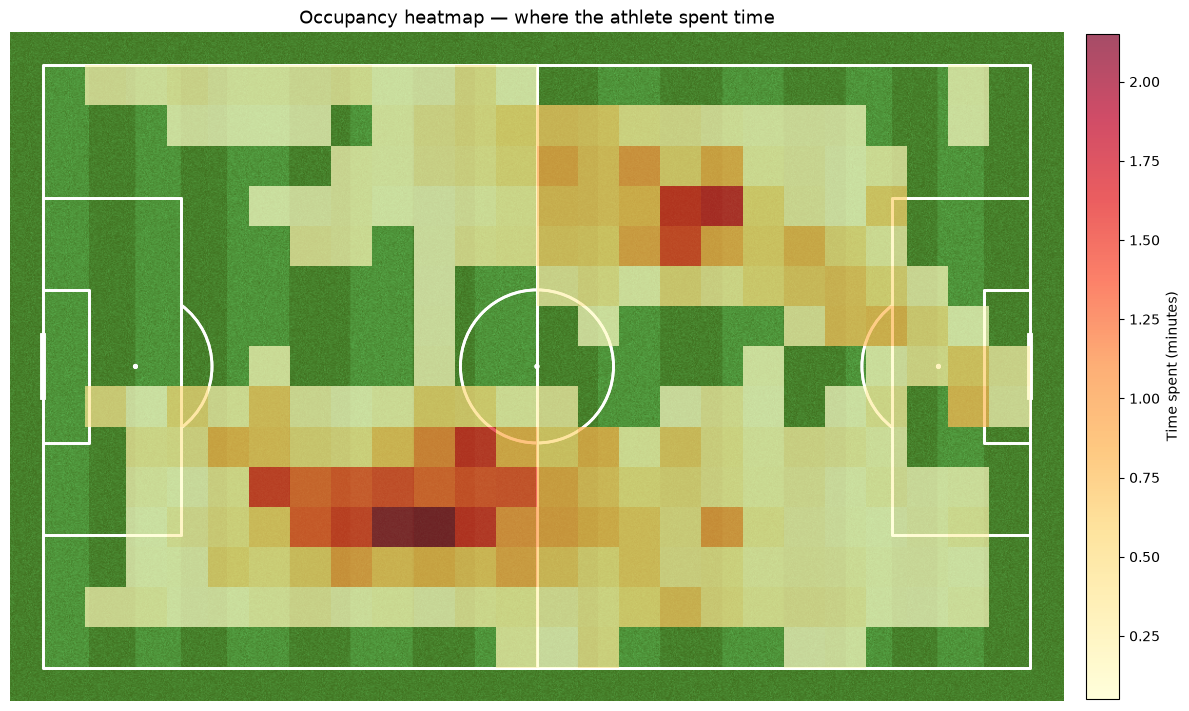

In [24]:
# Phase 4.3: Position heatmap (time-spent density)

from mplsoccer import Pitch
import numpy as np

pitch = Pitch(pitch_type='custom', pitch_length=118, pitch_width=72,
              pitch_color='grass', stripe=True,
              line_color='white', linewidth=2)

fig, ax = pitch.draw(figsize=(12, 8))

stat = pitch.bin_statistic(df["x_pos_m"], df["y_pos_m"],
                           statistic="count", bins=(24, 15))
stat["statistic"] = stat["statistic"] * 0.1 / 60          # counts -> minutes

# empty/low bins transparent so the grass shows through
stat["statistic"] = np.where(stat["statistic"] < 0.05, np.nan, stat["statistic"])

pcm = pitch.heatmap(stat, ax=ax, cmap="YlOrRd", alpha=0.7, zorder=1)
cbar = fig.colorbar(pcm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Time spent (minutes)")

# redraw lines on top
pitch.draw(ax=ax)

ax.set_title("Occupancy heatmap — where the athlete spent time", fontsize=13)
fig.savefig("../images/03_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

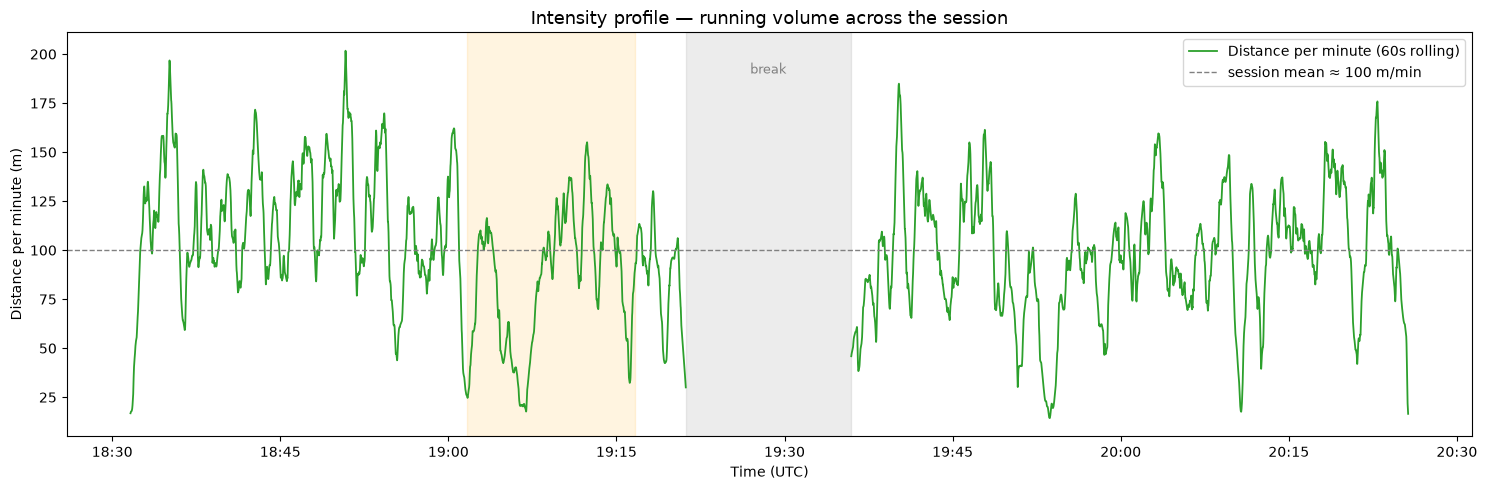

In [25]:
# Phase 4.4:  Intensity profile (rolling distance-per-minute)

import matplotlib.dates as mdates

# rolling 60s distance -> distance per minute, per half
# 600 samples = 60s; sum of dist_m over the window = metres covered in that minute
df["dist_per_min_roll"] = df.groupby("half")["dist_m"].transform(
    lambda s: s.rolling(600, center=True, min_periods=60).sum())

fig, ax = plt.subplots(figsize=(15, 5))

for h in ["H1", "H2"]:
    g = df[df["half"] == h]
    ax.plot(g["time"], g["dist_per_min_roll"], color="tab:green", linewidth=1.3,
            label="Distance per minute (60s rolling)" if h == "H1" else None)

# session mean line for reference
session_mean = df["dist_per_min_roll"].mean()
ax.axhline(session_mean, color="gray", linestyle="--", linewidth=1,
           label=f"session mean ≈ {session_mean:.0f} m/min")

# shade break
gap_start = df[df.half=="H1"]["time"].max()
gap_end   = df[df.half=="H2"]["time"].min()
ax.axvspan(gap_start, gap_end, color="gray", alpha=0.15)
ax.text(gap_start + (gap_end-gap_start)/2, df["dist_per_min_roll"].max()*0.97,
        "break", ha="center", va="top", fontsize=9, color="gray")

# shade B3 fatigue window
b3 = df[df.block=="H1-B3"]
ax.axvspan(b3["time"].min(), b3["time"].max(), color="orange", alpha=0.12)

ax.set_ylabel("Distance per minute (m)")
ax.set_xlabel("Time (UTC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_title("Intensity profile — running volume across the session", fontsize=13)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../images/04_intensity_profile.png", dpi=150, bbox_inches="tight")
plt.show()

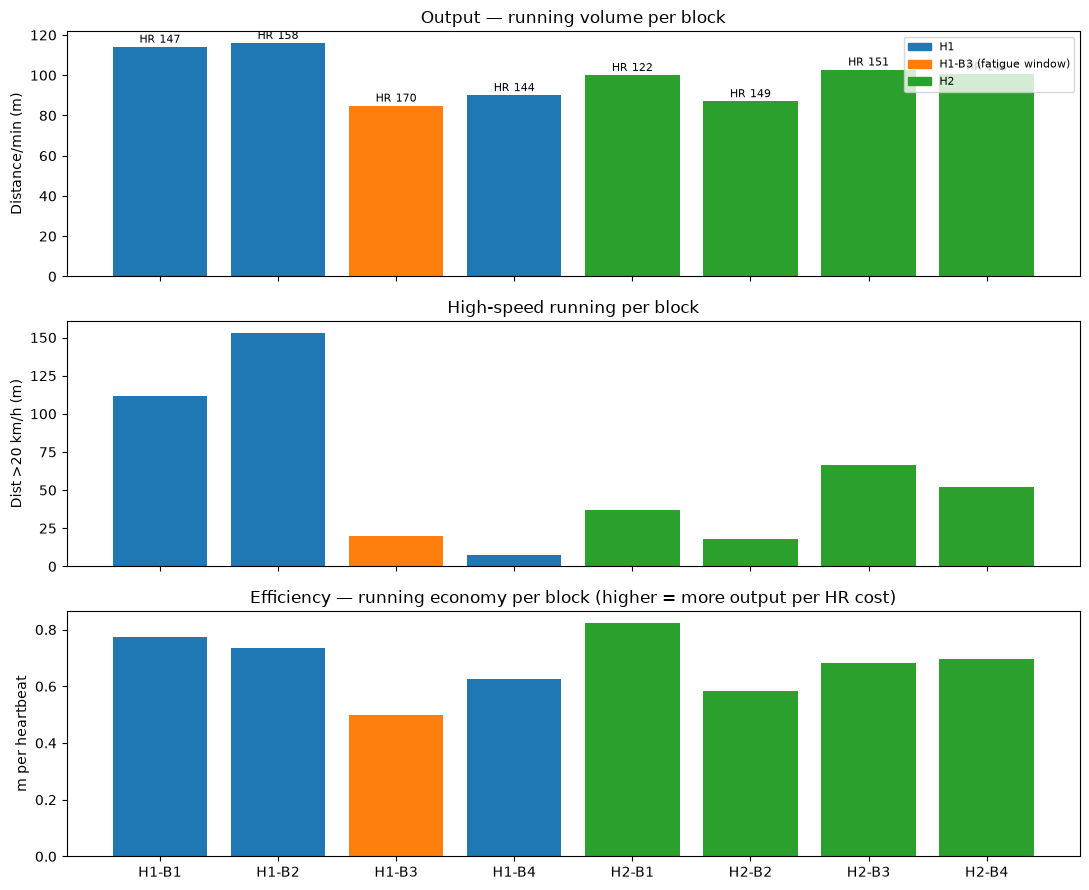

In [26]:
# Phase 4.5: Fatigue panel (per-block metrics)

# rebuild the per-block metrics (same as step 26) to be safe/self-contained
bm = df.groupby("block", sort=False).agg(
    duration_min=("dt", lambda s: s.sum()/60),
    dist_m=("dist_m", "sum"),
    mean_hr=("heartbeat_bpm", "mean"),
)
bm["dist_per_min"] = bm["dist_m"] / bm["duration_min"]
bm["m_per_beat"]  = bm["dist_per_min"] / bm["mean_hr"]
hi = df["speed_smooth_kmh"] >= 20
bm["dist_over20"] = df[hi].groupby(df["block"], sort=False)["dist_m"].sum().reindex(bm.index).fillna(0)

blocks = bm.index.tolist()
x = range(len(blocks))
# colour H1 vs H2, and flag the B3 fatigue block
colors = ["tab:orange" if b == "H1-B3" else ("tab:blue" if b.startswith("H1") else "tab:green")
          for b in blocks]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# panel 1: output
axes[0].bar(x, bm["dist_per_min"], color=colors)
axes[0].set_ylabel("Distance/min (m)")
axes[0].set_title("Output — running volume per block")
for i, v in enumerate(bm["mean_hr"]):
    axes[0].text(i, bm["dist_per_min"].iloc[i]+2, f"HR {v:.0f}", ha="center", fontsize=8)

# panel 2: high-speed running
axes[1].bar(x, bm["dist_over20"], color=colors)
axes[1].set_ylabel("Dist >20 km/h (m)")
axes[1].set_title("High-speed running per block")

# panel 3: efficiency index
axes[2].bar(x, bm["m_per_beat"], color=colors)
axes[2].set_ylabel("m per heartbeat")
axes[2].set_title("Efficiency — running economy per block (higher = more output per HR cost)")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(blocks, rotation=0)

# legend proxy
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="tab:blue", label="H1"),
                        Patch(color="tab:orange", label="H1-B3 (fatigue window)"),
                        Patch(color="tab:green", label="H2")],
               loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("../images/05_fatigue_panel.png", dpi=150, bbox_inches="tight")
plt.show()